# Aprendizaje Automático
# Proyecto Final

Profesor: Juan Luis Crespo Mariño

Instituto Tecnológico de Costa Rica,

Programa Ciencia de Datos

---



Medio de entrega: Por medio del TEC-Digital.

Entregables: Un archivo jupyter ( .IPYNB ).

BD utilizada: https://archive.ics.uci.edu/dataset/2/adult


Estudiante:
1. **Jose Pablo Ruiz Myrie**
2. **Nikole Villalobos Lopez**


# Notebook 03 — Modelo de Regresión Logística

En este notebook se entrena y evalúa una Regresión Logística como modelo
baseline para clasificar si el ingreso anual de una persona es superior a $50K.
Se utiliza la selección de variables y las decisiones de preprocesado definidas
en los notebooks anteriores.


In [1]:
pip install ucimlrepo

  Using cached pandas-3.0.5-cp311-cp311-macosx_11_0_arm64.whl.metadata (79 kB)
  Using cached numpy-2.4.6-cp311-cp311-macosx_14_0_arm64.whl.metadata (6.6 kB)
Using cached pandas-3.0.5-cp311-cp311-macosx_11_0_arm64.whl (10.0 MB)
Using cached numpy-2.4.6-cp311-cp311-macosx_14_0_arm64.whl (5.5 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [ucimlrepo]/3 [pandas]

[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
# ============================================================
# Preparamos el dataset y descargamos librerías
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from ucimlrepo import fetch_ucirepo
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score

#Cargamos el dataset
df = pd.read_csv("../data/datos_finales.csv")

print("Dataset preparado:", df.shape)
df.head()


ModuleNotFoundError: No module named 'matplotlib'

In [ ]:
# ============================================================
#  Selección de algoritmos y partición de datos
# ============================================================

# Se selecciona Regresión logística debido a que el problema que deseamos
# resolver es determinar si una persona gana más de 50k $ o no. Es decir,
# la variable objetivo es cátegorica binaria. Por lo que tenemos una tarea
# de clasificación. El modelo estima la probabilidad de pertenecer a una de las
# clases. La regresión logística pertenece a la familia de modelos lineales.
# Entre sus ventajas están: rapidez, interpretabilidad y que sus
# coeficientes permiten analizar la dirección e importancia relativa de las
# variables

# Se utiliza una partición 80 % entrenamiento / 20 % prueba donde la mayor parte
# de los datos se utiliza para que el modelo aprenda.

In [ ]:
# ============================================================
# Entrenamiento y ajuste de hiperparámetros
# ============================================================


# ------------------------------------------------------------
# 1. Preparar variable objetivo
# ------------------------------------------------------------
df_model = df.copy()

y_model = df_model["income"]

# ------------------------------------------------------------
# 2. Selección de variables
# ------------------------------------------------------------

# Los datos_finales ya contiene únicamente las variables seleccionadas, codificadas y escaladas

X_model = df_model.drop(columns=["income"])

# ------------------------------------------------------------
# 3.Separamiento de entrenamiento y prueba
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X_model,
    y_model,
    test_size=0.20,
    random_state=42,
    stratify=y_model
)

# ------------------------------------------------------------
# 4. Regresión logistica baseline
# ------------------------------------------------------------

logistic_baseline = LogisticRegression(max_iter=1000)

# Entrenamiento
logistic_baseline.fit(X_train, y_train)

# Predicciones
y_pred_baseline = logistic_baseline.predict(X_test)
y_prob_baseline = logistic_baseline.predict_proba(X_test)[:, 1]

# ============================================================
# 5 Evaluación comparativa
# ============================================================

# Realizamos la evaluación de la Regresión Logística mediante las métricas
# Accuracy, Precision, Recall, F1 y AUC-ROC

baseline_metrics = {
    "Modelo": "Regresión Logística - Baseline",
    "Accuracy": accuracy_score(y_test, y_pred_baseline),
    "Precision": precision_score(y_test, y_pred_baseline),
    "Recall": recall_score(y_test, y_pred_baseline),
    "F1": f1_score(y_test, y_pred_baseline),
    "AUC-ROC": roc_auc_score(y_test, y_prob_baseline)
}

for metric, value in baseline_metrics.items():
    if metric != "Modelo":
        print(f"{metric}: {value:.4f}")




Accuracy: 0.8435
Precision: 0.7078
Recall: 0.5894
F1: 0.6432
AUC-ROC: 0.8993


c:\Users\Usuario\Documents\Tec\Ciencia de Datos\Aprendizaje Automatico\Proyecto_final\proyecto_final_ml\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Usuario\Documents\Tec\Ciencia de Datos\Aprendizaje Automatico\Proyecto_final\proyecto_final_ml\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a 

                             Modelo  Accuracy  Precision  Recall      F1  \
0    Regresión Logística - Baseline    0.8435     0.7078  0.5894  0.6432   
1     Regresión Logística con C=0.1    0.8427     0.7070  0.5851  0.6403   
2      Regresión Logística con C=10    0.8427     0.7046  0.5898  0.6421   
3        Regresión Logística con L1    0.8430     0.7068  0.5877  0.6418   
4  Regresión Logística con Balanced    0.8000     0.5533  0.8529  0.6712   

   AUC-ROC  
0   0.8993  
1   0.8991  
2   0.8993  
3   0.8994  
4   0.8992  

Mejor modelo según F1:
Regresión Logística con Balanced


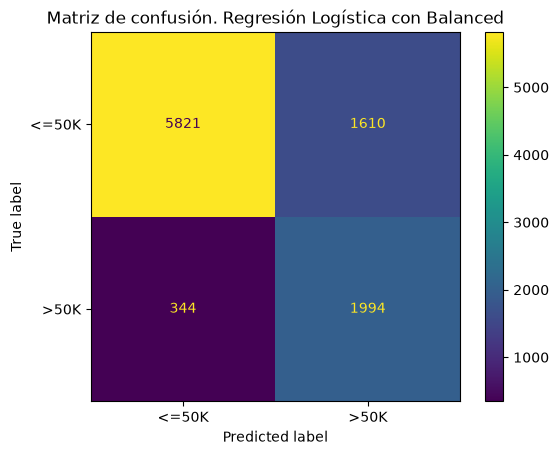

In [ ]:
# ============================================================
# Ajuste de hiperparámetros - Regresión Logística
# ============================================================

# Definimos diferentes combinaciones de hiperparámetros para analizar su 
# # efecto sobre el rendimiento del modelo

logistic_configurations = [

    {
        "Modelo": "Regresión Logística con C=0.1",
        "C": 0.1,
        "penalty": "l2",
        "class_weight": None
    },

    {
        "Modelo": "Regresión Logística con C=10",
        "C": 10.0,
        "penalty": "l2",
        "class_weight": None
    },

    {
        "Modelo": "Regresión Logística con L1",
        "C": 1.0,
        "penalty": "l1",
        "class_weight": None
    },

    {
        "Modelo": "Regresión Logística con Balanced",
        "C": 1.0,
        "penalty": "l2",
        "class_weight": "balanced"
    }
]

# Creamos una lista para almacenar los resultados
logistic_results = []

# Incluimos primero los resultados del modelo baseline
logistic_results.append(baseline_metrics)

# Creamos una lista para almacenar los modelos entrenados
logistic_models = {
    "Regresión Logística - Baseline": logistic_baseline
}

# Entrenamos cada configuración
for config in logistic_configurations:

    logistic_model = LogisticRegression(
        C=config["C"],
        penalty=config["penalty"],
        solver="liblinear",
        class_weight=config["class_weight"],
        max_iter=1000
    )

    # Entrenamiento
    logistic_model.fit(X_train, y_train)

    # Predicciones
    y_pred = logistic_model.predict(X_test)
    y_prob = logistic_model.predict_proba(X_test)[:, 1]

    # Calculamos las métricas
    metrics = {
        "Modelo": config["Modelo"],
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "AUC-ROC": roc_auc_score(y_test, y_prob)
    }

    logistic_results.append(metrics)

    # Guardamos el modelo entrenado
    logistic_models[config["Modelo"]] = logistic_model


# ------------------------------------------------------------
# 6. Comparación de resultados
# ------------------------------------------------------------

logistic_results_df = pd.DataFrame(logistic_results)
print(logistic_results_df.round(4))


# ------------------------------------------------------------
# 7. Selección del mejor modelo
# ------------------------------------------------------------

# Seleccionamos el modelo con mayor F1
best_model_name = logistic_results_df.loc[logistic_results_df["F1"].idxmax(),"Modelo"]
best_logistic_model = logistic_models[best_model_name]
print("\nMejor modelo según F1:")
print(best_model_name)

# ------------------------------------------------------------
# 8. Matriz de confusión del mejor modelo
# ------------------------------------------------------------

# Realizamos las predicciones con el mejor modelo
y_pred_mejor = best_logistic_model.predict(X_test)

# Calculamos la matriz de confusión
matriz_confusion = confusion_matrix(y_test, y_pred_mejor)

# Mostramos la matriz
disp = ConfusionMatrixDisplay(confusion_matrix=matriz_confusion, display_labels=["<=50K", ">50K"])
disp.plot()
plt.title(f"Matriz de confusión. {best_model_name}")
plt.show()

### Análisis Comparativo de los 5 modelos.

Al evaluar las distintas configuraciones de hiperparámetros para la regresión logística donde se modifica la regularización (C), el tipo de penalización (L) y ponderación de clases. Se puede observar como las moficacions de la regularización (C) y el tipo de penalización de L2 a L1 condujo a variaciones mínimas en el desempeño. Esto indica que el modelo tiene una baja sensibilidad a dichos hiperparámetros dentro de los valores que se analizan. Por otro lado, al utilizar la ponderación de las clase "balanced" se produjo un cambio considerable en el clasificador, donde, el recall aumentó de 0.5894 a 0.8529 y el F1 de 0.6432 a 0.6712, aunque la accuracy disminuyó de 0.8435 a 0.8000 y la precision de 0.7078 a 0.5533. Estp indica un compromiso entre la capacidad de detectar individuos con ingresos superiores a $50K y el aumento de falsos positivos. La selección del modelo final depende del objetivo para el cual deseamos identificar si la persona gana más o menos de USD $50k, así, si para la investigación fuera especialmente importante identificar correctamente a las personas que ganan más de $50K Balanced sería el modelo ganador. Esto debido a que, el modelo con Balanced está siendo mucho más agresivo al identificar personas como >$50K. Por eso encuentra muchos más positivos reales, pero también genera más falsos positivos. Por otro lado, si se priorizan la accuracy y la precision sobre la detección de la clase minoritaria, se debería mantener el modelo baseline. Para nuestro caso de estudio se ha seleccionado el modelo con "Balanced" como el ganador dentro de las regresiones logísticas ya que presentó el mayor F1 y un recall considerablemente superior, métricas especialmente relevantes para la identificación de la clase minoritaria >50K.

### Interpretación de los resultados de la Regresión Logística Ganadora (Balanced)

En este caso el modelo obtuvo una exactitud de 80.00%, lo que quiere decir que alrededor de 80 de cada 100 observaciones del conjunto de prueba fueron clasificadas de forma correcta. No obstante, como la variable objetivo cuenta con un desequilibrio moderado entre cada categoría de ingreso no se debe de utilizar esta métrica de forma aislada. Así, se cuenta con la precision, recall, F1 y AUC-ROC. Por su parte, se obtuvo una precision de 55.33%, lo que significa que del total de personas que el modelo clasificó como personas con ingresos superiores a $50K, alrededor del 55% pertenecía realmente a esta categoría. En cuanto al recall, se obtuvo un valor de 85.29%, lo que se traduce a que el modelo logró identificar de forma correcta al 85.29% de todos las observaciones que realmente cuentan con ingresos superiores a USD $50K. Esto evidencia que el modelo tiene una buena capacidad para detectar la clase minoritaria (>50K), aunque a costa de generar una mayor cantidad de falsos positivos. El F1 , que resume el equilibrio entre precision y recall, fue de 0.6712 lo que refleja un equilibrio moderado entre precision y recall y evidencia que aún existe margen de mejora, principalmente debido a la reducción de la precision causada por el aumento de falsos positivos. Finalmente, el AUC-ROC de 0.8992 lo que evidencia una buena capacidad de discriminación. Lo que significa que el modelo logra separar adecuadamente a los individuos con ingresos superiores a $50K de aquellos con ingresos iguales o inferiores a este nivel.

En lo que respecta a la matriz de confusión, podemos observar que Se clasificaron correctamente 5821 individuos con ingresos iguales o inferiores a $50K y 1994 individuos con ingresos superiores a $50K. Además, se registraron 1610 falsos positivos (personas clasificadas como >50K cuando realmente pertenecían a <=50K) y 344 falsos negativos (personas clasificadas como <=50K cuando realmente pertenecían a >50K). Así, podemos observar que existe un número considerablemente mayor de falsos positivos (1610) que de falsos negativos (344), lo que evidencia que el modelo tiende a clasificar de forma más agresiva a los individuos como >50K. La principal limitación del modelo se encuentra en su precision, ya que una cantidad importante de individuos con ingresos ≤50K son clasificados incorrectamente como >50K.

En síntesis, la regresión logística con "Balanced" presenta un buen desempeño global, especialmente considerando la exactitud cercana al 80% y el AUC-ROC de 0.8992. Sin embargo, el análisis de la matriz de confusión y del recall muestra que el modelo logra identificar una proporción elevada de los individuos con ingresos superiores a $50K, aunque esta mejora en recall se produce a costa de un aumento considerable de falsos positivos y una menor precision. Por esta razón, la evaluación del modelo debe considerar conjuntamente accuracy, precision, recall, F1 y AUC-ROC, y no basarse únicamente en una métrica. Así, en la comparación final con los demás modelos del proyecto, será importante verificar si algún algoritmo logra mantener un AUC-ROC similar o superior, pero al mismo tiempo mejorar el recall y el F1 de la clase >50K, ya que eso representaría una mejor identificación de la clase minoritaria.

In [ ]:
# ============================================================
# Interpretación de variables numéricas y categórica binaria
# ============================================================

selected_interpretation_variables = [
    "standard__age",
    "standard__education-num",
    "standard__capital-gain-log",
    "standard__capital-loss-log",
    "robust__hours-per-week",
    "categorical__sex_Male"
]

selected_coef_df = coef_df[coef_df["Variable"].isin(selected_interpretation_variables)].copy()

selected_coef_df


,Variable,Coeficiente,Odds Ratio
1,standard__education-num,0.728896,2.072791
40,categorical__sex_Male,0.662030,1.938723
2,standard__capital-gain-log,0.514271,1.672419
0,standard__age,0.314683,1.369824
3,standard__capital-loss-log,0.236411,1.266694
4,robust__hours-per-week,0.158297,1.171515


Al analizar los coeficientes y los odds ratios de las variables númericas podemos ver como todos los coeficientes son positivos, por lo que se aoscian con una mayor probabilidad de pertenecer al grupo de >50K, manteniendo constantes las demás variables. Así, education-num es la vairbale númerica con mayor peso positivo en la regresión, su coeficiente de 0.729 y odds ratio de 2.073 nos indican que un aumento de una desviación estándar en el nivel educativo se asocia con unas odds aproximadamente 2.07 veces mayores de superar los $50K lo que concuerda con el comportamiento esperado donde se esperaría que una mayor educación permitan el acceso a puestos de mayor remuneración. En cuanto a capital-gain-log con un coeficiente positivo de 0.514 y un odds ratio de 1.672, nos indica que mayores valores de ganancias de capital están asociados con mayores odds de pertenecer al grupo de ingresos superiores a $50K, En otras palabras, un aumento de una desviación estándar en la variable transformada se asocia con unas odds aproximadamente 67.2% mayores, manteniendo constantes las demás características. En cuanto a age, se presenta una asociación positiva moderada con los ingresos superiores a $50K. Su odds ratio de 1.370 indica que un aumento de una desviación estándar en la edad se asocia con unas odds aproximadamente 37.0% mayores de pertenecer a la categoría de ingresos altos, manteniendo constantes las demás variables. Esto concuerda con el comportamiento esperado sobre la acumulación de experiencia laboral, conocimientos y progresión profesional a lo largo del tiempo Con respecto a capital-loss-log, presenta una asociación positiva con los ingresos superiores a $50K. Aquí, el odds ratio de 1.267 indica unas odds aproximadamente 26.7% mayores ante un incremento de una desviación estándar en la variable transformada Ahora bien, una pérdida de capital podría parecer asociada negativamente con el ingreso, no obstante este resultado podría reflejar que los individuos con mayores ingresos presentan una mayor participación en activos o inversiones y, por tanto, también una mayor posibilidad de registrar pérdidas de capital. En cuanto a hours-per-week, el odds ratio de 1.172 indica que aumentos en las horas trabajadas, están asociados con mayores odds de pertenecer al grupo de ingresos superiores a $50K. Sin embargo, el efecto es menor que el observado para variables como educación o ganancias de capital. Por otro lado, la categoría Male presenta un coeficiente positivo de 0.662 y un odds ratio de 1.939. Así, se tiene que manteniendo constantes las demás variables del modelo, los hombres presentan unas odds aproximadamente 1.94 veces mayores de pertenecer al grupo de ingresos superiores a $50K en comparación con las mujeres. Es impotante que el resultado debe interpretarse como una asociación estadística observada en el conjunto de datos y no como una relación causal. En síntesis, el análisis de los coeficientes de la regresión logística muestra que todas las variables numéricas presentan una asociación positiva con la probabilidad de obtener ingresos superiores a $50K donde factores relacionados con el nivel educativo, la acumulación de capital y la experiencia asociada con la edad presentan una relación más fuerte con los ingresos altos que la cantidad de horas trabajadas por semana.